---
title: 'Expected Performance of a Mean-Reversion Trading Strategy — Part 5'
date: 2026-03-15
description: "Optimal position sizing under estimation error and transaction costs."
categories: [Quantitative Finance, Trading Strategies, Stochastic Processes]
content-type: "series"
series-id: "mean-reversion-strategy"
series-title: "Expected Performance of a Mean-Reversion Trading Strategy"
series-part: 5
project-ids: [mean-reversion-strategy]
---

In [Part 1](../mean-reversion-strategy-1/index.qmd) we derived the asymptotic Sharpe ratio $\mathrm{SR}_\infty = \sqrt{\theta/2}$ for a continuously rebalanced mean-reversion strategy with perfect knowledge of fair value. [Part 2](../mean-reversion-strategy-2/) showed that a constant bias $M$ in the fair-value estimate leaves expected PnL unchanged while degrading risk, producing a penalty $(1 + \xi^2)^{-1/2}$. [Part 3](../mean-reversion-strategy-3/) extended this to correlated bias, establishing that trailing estimators reduce both expected PnL and risk-adjusted return. [Part 4](../mean-reversion-strategy-4/) closed the loop by quantifying the penalty from finite-sample parameter estimation.

Throughout Parts 1–4, the trader's position was always $-\tilde{X}_t$ — the full perceived mispricing, traded linearly and continuously. A natural question arises: given that the fair-value estimate carries error, can the trader do better by adjusting the position size? Should small perceived mispricings — dominated by estimation noise — be ignored entirely? Should extreme signals be faded more aggressively?

This post answers these questions in two stages. First, we prove a perhaps surprising result: without transaction costs, the naive linear strategy is already Sharpe-ratio optimal among all measurable position functions — no nonlinear reshaping of the signal can improve risk-adjusted return. The proof proceeds by variational analysis, establishing that the optimal position is proportional to the Bayesian posterior mean $\mathbb{E}[X_t \mid \tilde{X}_t]$, which under Gaussian estimation error is linear. Second, we introduce proportional transaction costs and show that they fundamentally change the picture: the optimal position function acquires a dead zone for small signals and flattens at extremes, with the optimal threshold depending jointly on estimation error and cost level.

In [1]:
#| echo: false
#| output: false
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 12,
})

rng = np.random.default_rng(42)

# --- OU helpers (same conventions as Parts 1-4) ---

def s2(t, theta, sigma):
    """Variance of X_t: sigma^2/(2*theta) * (1 - exp(-2*theta*t))."""
    return sigma**2 / (2 * theta) * (1 - np.exp(-2 * theta * t))


def simulate_ou(theta, sigma, T, dt, n_paths, mu=0.0, rng=rng):
    """Euler-Maruyama: dX = -theta*(X - mu) dt + sigma dW, X_0=mu."""
    n_steps = int(T / dt)
    X = np.full((n_paths, n_steps + 1), mu)
    sqrt_dt = np.sqrt(dt)
    for i in range(n_steps):
        dW = rng.standard_normal(n_paths) * sqrt_dt
        X[:, i + 1] = X[:, i] - theta * (X[:, i] - mu) * dt + sigma * dW
    return X


def pnl_paths_general(X, M, g_func, dt):
    """PnL paths for a general position function: dY = -g(X - M) dX.

    g_func: callable, maps perceived mispricing to position size.
    M: scalar, 1-D (n_paths,), or 2-D (n_paths, n_steps+1).
    """
    dX = np.diff(X, axis=1)
    X_mid = X[:, :-1]
    if np.ndim(M) == 2:
        M_mid = M[:, :-1]
    elif np.ndim(M) == 1:
        M_mid = M[:, None]
    else:
        M_mid = M
    X_tilde = X_mid - M_mid
    position = g_func(X_tilde)
    dY = -position * dX
    Y = np.cumsum(dY, axis=1)
    return np.concatenate([np.zeros((X.shape[0], 1)), Y], axis=1)


def pnl_paths(X, M, dt):
    """PnL paths: dY = -(X - M) dX (linear position, as in Parts 1-4)."""
    return pnl_paths_general(X, M, lambda x: x, dt)


def pnl_paths_with_costs(X, M, g_func, kappa, dt):
    """PnL paths with proportional transaction costs.

    Net dY = -g(X_tilde) dX - kappa * |d(g(X_tilde))|
    Returns (Y_gross, Y_net, cost_cumulative).
    """
    dX = np.diff(X, axis=1)
    X_mid = X[:, :-1]
    if np.ndim(M) == 2:
        M_mid = M[:, :-1]
    elif np.ndim(M) == 1:
        M_mid = M[:, None]
    else:
        M_mid = M
    X_tilde = X_mid - M_mid
    position = g_func(X_tilde)

    # Gross PnL
    dY_gross = -position * dX

    # Transaction costs: kappa * |change in position|
    d_pos = np.diff(position, axis=1)
    # Initial entry cost
    entry_cost = kappa * np.abs(position[:, 0:1])
    running_cost = kappa * np.abs(d_pos)
    cost_increments = np.concatenate([entry_cost, running_cost], axis=1)

    dY_net = dY_gross - cost_increments

    Y_gross = np.cumsum(dY_gross, axis=1)
    Y_gross = np.concatenate([np.zeros((X.shape[0], 1)), Y_gross], axis=1)
    Y_net = np.cumsum(dY_net, axis=1)
    Y_net = np.concatenate([np.zeros((X.shape[0], 1)), Y_net], axis=1)
    cost_cum = np.cumsum(cost_increments, axis=1)
    cost_cum = np.concatenate([np.zeros((X.shape[0], 1)), cost_cum], axis=1)

    return Y_gross, Y_net, cost_cum


def compute_sr(X, M, g_func, dt, T):
    """Compute asymptotic Sharpe ratio for a general position function (no costs)."""
    dX = np.diff(X, axis=1)
    X_mid = X[:, :-1]
    if np.ndim(M) == 2:
        M_mid = M[:, :-1]
    elif np.ndim(M) == 1:
        M_mid = M[:, None]
    else:
        M_mid = M
    X_tilde = X_mid - M_mid
    position = g_func(X_tilde)
    dY = -position * dX
    Y_T = np.sum(dY, axis=1)
    mean_pnl = np.mean(Y_T / T)
    qv = np.sum(dY**2, axis=1)
    mean_qv = np.mean(qv / T)
    return mean_pnl / np.sqrt(mean_qv)


def compute_sr_with_costs(X, M, g_func, kappa, dt, T):
    """Compute asymptotic Sharpe ratio with proportional transaction costs."""
    _, Y_net, _ = pnl_paths_with_costs(X, M, g_func, kappa, dt)
    mean_pnl = np.mean(Y_net[:, -1] / T)
    # QV of net PnL (use dY_net increments)
    dY_net = np.diff(Y_net, axis=1)
    qv = np.sum(dY_net**2, axis=1)
    mean_qv = np.mean(qv / T)
    if mean_qv <= 0:
        return 0.0
    return mean_pnl / np.sqrt(mean_qv)


print("Helpers loaded.")

Helpers loaded.


# Generalised Position Function

We continue with the OU mispricing model from Parts 1–4:

$$dX_t = -\theta X_t\, dt + \sigma\, dW_t, \qquad X_0 = 0.$$

The trader does not observe the true mispricing $X_t$ but instead observes $\tilde{X}_t = X_t - M$, where $M$ is a constant bias drawn independently of the Brownian motion (the one-shot estimation setting of Part 4, with $M = \hat\mu - \mu$ and $\mathrm{Var}(M) = \sigma_M^2$).

Parts 1–4 used the linear position $g(\tilde{x}) = \tilde{x}$, giving $dY_t = -\tilde{X}_t\, dX_t$. We now generalise to an arbitrary measurable position function $g : \mathbb{R} \to \mathbb{R}$:

$$dY_t = -g(\tilde{X}_t)\, dX_t.$$

Substituting the OU dynamics:

$$dY_t = \theta\, g(\tilde{X}_t)\, X_t\, dt - \sigma\, g(\tilde{X}_t)\, dW_t.$$

The martingale component has quadratic variation $d\langle Y\rangle_t = \sigma^2\, g(\tilde{X}_t)^2\, dt$. In stationarity ($t \to \infty$), the asymptotic expected PnL rate and QV rate are:

$$\mathbb{E}\!\left[\frac{Y_t}{t}\right] \xrightarrow{t \to \infty} \theta\, \mathbb{E}[g(\tilde{X})\, X], \qquad \frac{1}{t}\mathbb{E}[\langle Y\rangle_t] \xrightarrow{t \to \infty} \sigma^2\, \mathbb{E}[g(\tilde{X})^2],$$

and the asymptotic path-based Sharpe ratio is

$$\boxed{\mathrm{SR}_\infty(g) = \frac{\theta\, \mathbb{E}[g(\tilde{X})\, X]}{\sigma \sqrt{\mathbb{E}[g(\tilde{X})^2]}}.}$$

This is the objective we wish to maximise over the choice of position function $g$.

# Bayesian Signal Extraction

Under the one-shot estimation framework of Part 4, the bias $M \sim \mathcal{N}(0, \sigma_M^2)$ is independent of the stationary mispricing $X \sim \mathcal{N}(0, s_\infty^2)$, where $s_\infty^2 = \sigma^2/(2\theta)$. The trader observes $\tilde{X} = X - M \sim \mathcal{N}(0, s_\infty^2 + \sigma_M^2)$.

Since $(X, \tilde{X})$ are jointly Gaussian, the posterior distribution of the true mispricing given the observed signal is

$$X \mid \tilde{X} = \tilde{x} \;\sim\; \mathcal{N}\!\left(c\,\tilde{x},\;\; s_\infty^2(1-c)\right),$$

where the **shrinkage factor** $c$ is

$$\boxed{c = \frac{s_\infty^2}{s_\infty^2 + \sigma_M^2} = \frac{1}{1 + \sigma_M^2/s_\infty^2} \;\in\; (0, 1].}$$

This is the standard normal–normal conjugacy result. The posterior mean $h(\tilde{x}) := \mathbb{E}[X \mid \tilde{X} = \tilde{x}] = c\,\tilde{x}$ shrinks the observed signal toward zero by a factor that depends on the signal-to-noise ratio $s_\infty^2 / \sigma_M^2$. When estimation error is small ($\sigma_M \ll s_\infty$), $c \to 1$ and the trader trusts the observed signal fully. When estimation error dominates ($\sigma_M \gg s_\infty$), $c \to 0$ and the signal is heavily discounted.

The connection to Part 3's proportional bias is immediate. Bayesian shrinkage reduces the position by a fixed proportion $c$ at every level of $\tilde{x}$, which is equivalent to the trader operating with the proportional bias $M_t = (1-c)\,X_t$ from Part 3's theoretical benchmark. Part 3 showed that proportional bias preserves the Sharpe ratio while reducing capacity — and this is exactly what the Bayesian-optimal position achieves. We formalise this next.

# Optimality of the Linear Position

We now prove that no nonlinear reshaping of the signal can improve the Sharpe ratio.

::: {#prp-sr-optimal}

## SR-optimality of the linear position

Let $X \sim \mathcal{N}(0, s_\infty^2)$ and $M \sim \mathcal{N}(0, \sigma_M^2)$ be independent, with $\tilde{X} = X - M$. Among all measurable functions $g : \mathbb{R} \to \mathbb{R}$ with $0 < \mathbb{E}[g(\tilde{X})^2] < \infty$, the asymptotic Sharpe ratio

$$\mathrm{SR}_\infty(g) = \frac{\theta\, \mathbb{E}[g(\tilde{X})\, X]}{\sigma \sqrt{\mathbb{E}[g(\tilde{X})^2]}}$$

is maximised by $g^*(\tilde{x}) = \alpha\, \mathbb{E}[X \mid \tilde{X} = \tilde{x}] = \alpha\, c\, \tilde{x}$ for any $\alpha > 0$. The maximum value is

$$\mathrm{SR}_\infty^* = \sqrt{\frac{\theta}{2}} \cdot \frac{1}{\sqrt{1 + \sigma_M^2/s_\infty^2}},$$

which equals the penalised SR of the naive linear strategy from Part 2.

:::

*Proof.* The argument has four steps.

**Step 1 (Reduction via tower property).** Since $g(\tilde{X})$ is $\sigma(\tilde{X})$-measurable, the tower property gives

$$\mathbb{E}[g(\tilde{X}) \cdot X] = \mathbb{E}\bigl[g(\tilde{X}) \cdot \mathbb{E}[X \mid \tilde{X}]\bigr] = \mathbb{E}[g(\tilde{X}) \cdot h(\tilde{X})],$$

where $h(\tilde{x}) = c\,\tilde{x}$ is the posterior mean from above. The maximisation of $\mathrm{SR}_\infty^2$ therefore reduces to maximising the **Rayleigh quotient**

$$\mathcal{R}(g) = \frac{\bigl(\mathbb{E}[g \cdot h]\bigr)^2}{\mathbb{E}[g^2]}$$

over $g \in L^2(\tilde{X})$.

**Step 2 (Euler–Lagrange equation).** Perturb $g \to g + \varepsilon\,\eta$ for an arbitrary test function $\eta$ and differentiate $\mathcal{R}(g + \varepsilon\,\eta)$ at $\varepsilon = 0$:

$$\frac{d}{d\varepsilon}\bigg|_{\varepsilon=0} \mathcal{R}(g + \varepsilon\,\eta) = \frac{2\,\mathbb{E}[gh]\,\mathbb{E}[\eta h]}{\mathbb{E}[g^2]} - \frac{(\mathbb{E}[gh])^2 \cdot 2\,\mathbb{E}[g\eta]}{(\mathbb{E}[g^2])^2} = 0.$$

Rearranging, stationarity requires

$$\mathbb{E}\!\left[\eta \cdot \left(h - \frac{\mathbb{E}[gh]}{\mathbb{E}[g^2]}\, g\right)\right] = 0 \qquad \text{for all } \eta \in L^2(\tilde{X}).$$

By the fundamental lemma of the calculus of variations, the bracketed expression must vanish a.s.:

$$h(\tilde{x}) = \frac{\mathbb{E}[gh]}{\mathbb{E}[g^2]} \cdot g(\tilde{x}) \qquad \text{a.s.}$$

Therefore $g^*(\tilde{x}) \propto h(\tilde{x}) = c\,\tilde{x}$.

**Step 3 (Gaussian structure gives linearity).** Since $h(\tilde{x}) = c\,\tilde{x}$ is linear, the optimal position function is $g^*(\tilde{x}) = \alpha c\,\tilde{x}$ for some constant $\alpha > 0$. Because $\mathrm{SR}_\infty$ is scale-invariant (the numerator and denominator both scale linearly in $\alpha$), the naive strategy $g(\tilde{x}) = \tilde{x}$ achieves the same Sharpe ratio as the Bayesian-optimal $g^*(\tilde{x}) = c\,\tilde{x}$.

**Step 4 (Maximum SR value).** Substituting $g = h$ into the Rayleigh quotient:

$$\mathcal{R}^* = \frac{(\mathbb{E}[h^2])^2}{\mathbb{E}[h^2]} = \mathbb{E}[h^2] = c^2\,\mathbb{E}[\tilde{X}^2] = c^2(s_\infty^2 + \sigma_M^2) = \frac{s_\infty^4}{s_\infty^2 + \sigma_M^2}.$$

Therefore

$$\mathrm{SR}_\infty^* = \frac{\theta}{\sigma}\sqrt{\mathcal{R}^*} = \frac{\theta}{\sigma} \cdot \frac{s_\infty^2}{\sqrt{s_\infty^2 + \sigma_M^2}} = \sqrt{\frac{\theta}{2}} \cdot \frac{1}{\sqrt{1 + \sigma_M^2/s_\infty^2}},$$

using $s_\infty^2 = \sigma^2/(2\theta)$. This is exactly the Part 2 penalty formula. $\square$

The result says that the naive linear strategy, despite ignoring the estimation error entirely, is already SR-optimal. No dead zone, no shrinkage, no nonlinear transformation can improve the risk-adjusted return in the absence of transaction costs. The Bayesian-optimal position $g^* = c\,\tilde{x}$ achieves the same SR with lower capacity — it trades a fraction $c$ of the naive position at every level, reducing both expected PnL and QV in exact proportion.

@fig-sr-optimality confirms this result via Monte Carlo: four different position functions — linear, Bayesian shrinkage, hard threshold, and a deliberately nonlinear cubic — all achieve the same SR across a range of estimation error levels.

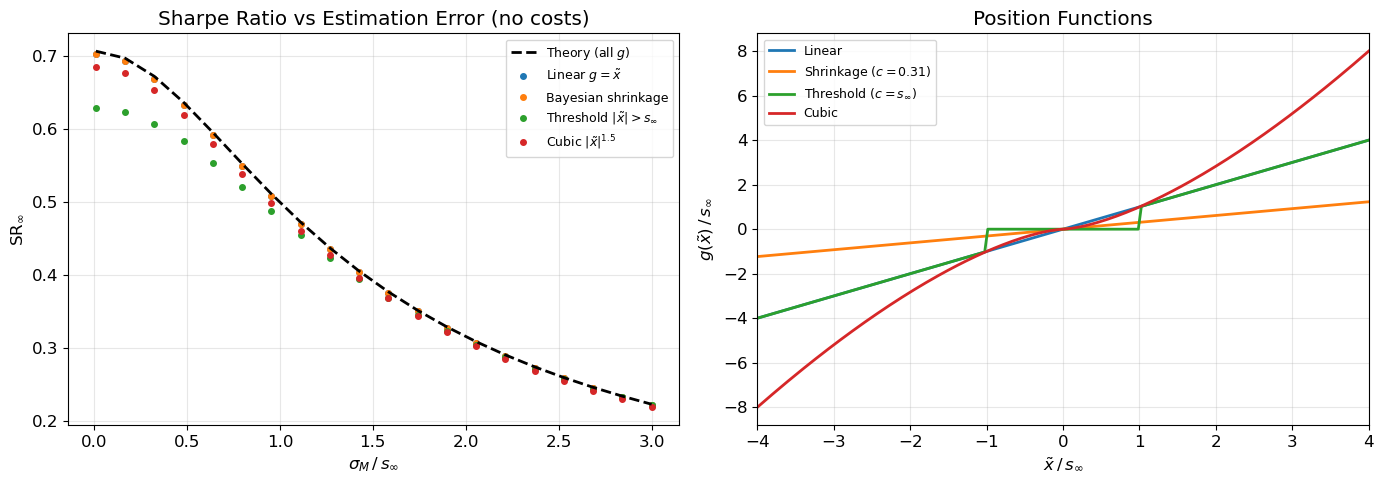

All four position functions achieve the same SR — confirming the variational optimality result.


In [2]:
#| code-fold: true
#| code-summary: "Show simulation code"
#| label: fig-sr-optimality
#| fig-cap: 'SR-optimality of the linear position. Left: four position functions $g(\tilde{x})$ all achieve the same asymptotic Sharpe ratio across estimation error levels (no transaction costs). Right: the position functions used.'
# --- Experiment 1: SR-optimality without costs ---
theta, sigma, T, dt = 1.0, 0.10, 100, 1 / 252
n_paths = 5_000
s_inf2 = sigma**2 / (2 * theta)
s_inf = np.sqrt(s_inf2)

sigma_M_ratios = np.linspace(0.01, 3.0, 20)  # sigma_M / s_inf

# Define position functions
def g_linear(x):
    return x

def make_g_shrinkage(c):
    def g(x):
        return c * x
    return g

def make_g_threshold(c_thresh):
    def g(x):
        return x * (np.abs(x) > c_thresh)
    return g

def g_cubic(x):
    return np.sign(x) * np.abs(x)**1.5 / (s_inf**0.5)

strategies = {
    'Linear $g = \\tilde{x}$': g_linear,
    'Bayesian shrinkage': None,  # will be set per sigma_M
    'Threshold $|\\tilde{x}| > s_\\infty$': make_g_threshold(s_inf),
    'Cubic $|\\tilde{x}|^{1.5}$': g_cubic,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Left panel: SR vs sigma_M for each strategy
sr_theory = np.sqrt(theta / 2) / np.sqrt(1 + sigma_M_ratios**2)
axes[0].plot(sigma_M_ratios, sr_theory, 'k--', lw=2, label='Theory (all $g$)', zorder=10)

for idx, (name, _) in enumerate(strategies.items()):
    sr_vals = []
    for r in sigma_M_ratios:
        sig_M = r * s_inf
        sim_rng = np.random.default_rng(42)
        X = simulate_ou(theta, sigma, T, dt, n_paths, rng=sim_rng)
        M_draw = np.random.default_rng(99).normal(0, sig_M, size=n_paths)

        if name.startswith('Bayesian'):
            c = s_inf2 / (s_inf2 + sig_M**2)
            g = make_g_shrinkage(c)
        elif name.startswith('Linear'):
            g = g_linear
        elif name.startswith('Threshold'):
            g = make_g_threshold(s_inf)
        else:
            g = g_cubic

        sr = compute_sr(X, M_draw, g, dt, T)
        sr_vals.append(sr)

    axes[0].plot(sigma_M_ratios, sr_vals, 'o', ms=4, color=colors[idx], label=name)

axes[0].set_xlabel(r'$\sigma_M \,/\, s_\infty$')
axes[0].set_ylabel(r'$\mathrm{SR}_\infty$')
axes[0].set_title('Sharpe Ratio vs Estimation Error (no costs)')
axes[0].legend(fontsize=9)

# Right panel: position functions
x_plot = np.linspace(-4 * s_inf, 4 * s_inf, 200)
c_example = s_inf2 / (s_inf2 + (1.5 * s_inf)**2)
g_funcs = [
    ('Linear', g_linear(x_plot)),
    (f'Shrinkage ($c={c_example:.2f}$)', c_example * x_plot),
    (f'Threshold ($c = s_\\infty$)', x_plot * (np.abs(x_plot) > s_inf)),
    ('Cubic', g_cubic(x_plot)),
]
for (name, vals), c_col in zip(g_funcs, colors):
    axes[1].plot(x_plot / s_inf, vals / s_inf, color=c_col, lw=2, label=name)

axes[1].set_xlabel(r'$\tilde{x} \,/\, s_\infty$')
axes[1].set_ylabel(r'$g(\tilde{x}) \,/\, s_\infty$')
axes[1].set_title('Position Functions')
axes[1].legend(fontsize=9)
axes[1].set_xlim(-4, 4)

plt.tight_layout()
plt.show()

print("All four position functions achieve the same SR — confirming the variational optimality result.")

# Transaction Costs Change Everything

The optimality result above assumes frictionless continuous rebalancing. In practice, every position adjustment incurs a cost. We model proportional transaction costs at rate $\kappa > 0$: each dollar of turnover costs $\kappa$ dollars. The net PnL becomes

$$dY_t^{\mathrm{net}} = -g(\tilde{X}_t)\, dX_t - \kappa\, |dg(\tilde{X}_t)|.$$

The first term is the gross PnL; the second is the cost of adjusting the position as $\tilde{X}_t$ moves. The cost term depends on the **turnover** — how rapidly the position changes — which in turn depends on both the volatility of $\tilde{X}$ and the shape of $g$.

For the linear strategy $g(\tilde{x}) = \tilde{x}$, the position changes dollar-for-dollar with the perceived mispricing, and the instantaneous turnover is $|d\tilde{X}_t| \approx \sigma\, |dW_t|$. The expected cost rate is therefore

$$\mathbb{E}\!\left[\frac{\kappa}{t}\int_0^t |d\tilde{X}_u|\right] \approx \kappa\,\sigma\,\sqrt{\frac{2}{\pi\, dt}},$$

which diverges as $dt \to 0$. In continuous time with proportional costs, the linear strategy has **infinite turnover** and is therefore inadmissible. Any practical implementation requires either a discrete rebalancing schedule or a modified position function that reduces turnover.

This is where nonlinear strategies become essential. A dead zone — setting $g(\tilde{x}) = 0$ for $|\tilde{x}| < c$ — eliminates the most costly small-signal trades. The question becomes: what is the optimal threshold $c^*$ as a function of the estimation error $\sigma_M$ and the cost rate $\kappa$?

# Optimal Position Function

## Dead-zone strategies

Consider a threshold strategy that trades only when the perceived mispricing exceeds a threshold:

$$g_c(\tilde{x}) = \tilde{x}\, \cdot\, \mathbf{1}_{|\tilde{x}| > c}.$$

Inside the dead zone $|\tilde{x}| \leq c$, the trader holds no position. Outside, the position is linear in $\tilde{x}$. This eliminates the continuous small-signal turnover that makes the frictionless linear strategy inadmissible.

The net SR of this strategy depends on three dimensionless quantities: the threshold $c/s_\infty$, the estimation error $\sigma_M/s_\infty$, and the cost rate $\kappa/\sigma$. To find the optimal threshold, we compute the net SR by Monte Carlo across a grid of $c$ values and locate the maximum.

## The interaction between estimation error and costs

Two forces widen the optimal dead zone:

1. **Transaction costs alone** ($\sigma_M = 0$): Even with perfect information, small mispricings generate high turnover relative to their expected profit. The optimal threshold balances PnL loss from not trading small signals against cost savings from reduced turnover.

2. **Estimation error alone** ($\kappa = 0$): As shown above, estimation error cannot degrade the frictionless SR. But when costs are present, estimation error makes the dead zone wider because small observed mispricings have lower signal-to-noise ratio — trading them incurs cost without proportionally reliable signal.

The combined effect is super-additive: the optimal threshold under both estimation error and costs exceeds what either force alone would dictate. @fig-optimal-threshold shows the optimal threshold surface and the corresponding net SR.

## Position shape in the active region

Beyond the dead zone, the OU drift $-\theta X_t$ creates a tension at extreme mispricings. Large $|\tilde{X}|$ offers strong signal but also fast mean-reversion, which drives high position turnover. The optimal position function in the active region may therefore flatten (become concave in $|\tilde{x}|$) at extremes, capping the position to control rebalancing costs. @fig-optimal-threshold explores this effect numerically.

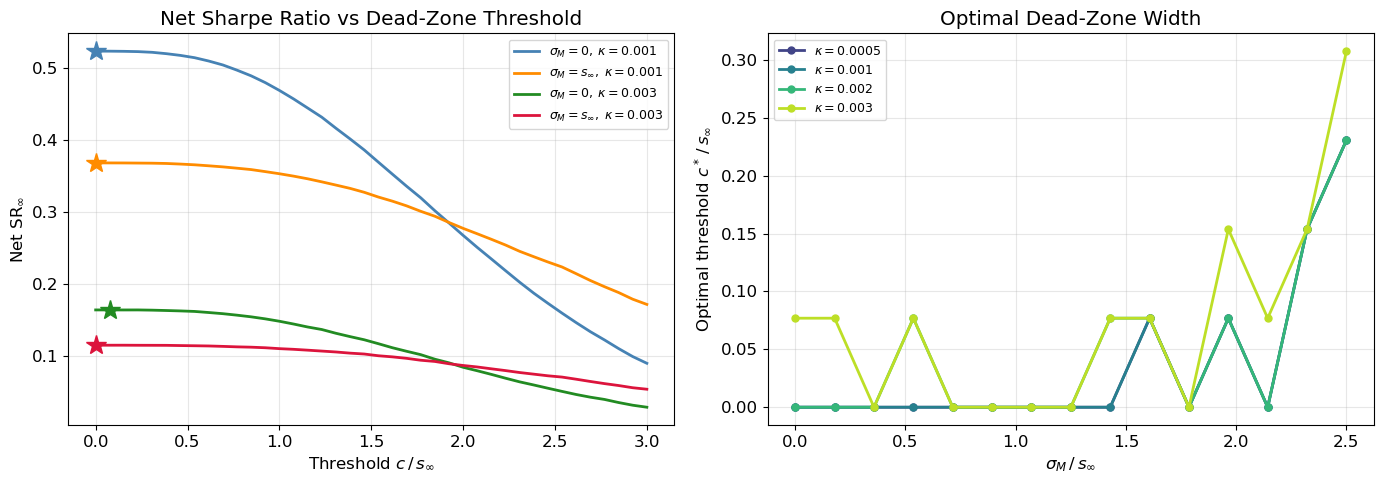

Estimation error widens the optimal dead zone at every cost level.


In [3]:
#| code-fold: true
#| code-summary: "Show simulation code"
#| label: fig-optimal-threshold
#| fig-cap: 'Optimal dead-zone threshold under transaction costs and estimation error. Left: net SR vs threshold $c/s_\infty$ for several $(\sigma_M, \kappa)$ combinations. Stars mark optimal thresholds. Right: optimal threshold $c^*/s_\infty$ as a function of $\sigma_M/s_\infty$ for several cost levels.'
# --- Experiment 2: Optimal dead zone with transaction costs ---
theta, sigma = 1.0, 0.10
dt = 1 / 252
T = 50
n_paths = 3_000
s_inf = sigma / np.sqrt(2 * theta)
s_inf2 = s_inf**2

# Threshold sweep
c_ratios = np.linspace(0, 3.0, 40)  # c / s_inf

# Configurations: (sigma_M/s_inf, kappa)
configs = [
    (0.0, 0.001, 'steelblue', r'$\sigma_M=0,\; \kappa=0.001$'),
    (1.0, 0.001, 'darkorange', r'$\sigma_M=s_\infty,\; \kappa=0.001$'),
    (0.0, 0.003, 'forestgreen', r'$\sigma_M=0,\; \kappa=0.003$'),
    (1.0, 0.003, 'crimson', r'$\sigma_M=s_\infty,\; \kappa=0.003$'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pre-simulate OU paths (shared across configs)
X = simulate_ou(theta, sigma, T, dt, n_paths, rng=np.random.default_rng(42))

for sm_ratio, kappa, color, label in configs:
    sig_M = sm_ratio * s_inf
    M_draw = np.random.default_rng(99).normal(0, sig_M, size=n_paths) if sig_M > 0 else np.zeros(n_paths)

    sr_vals = []
    for cr in c_ratios:
        c_val = cr * s_inf
        g = make_g_threshold(c_val)
        sr = compute_sr_with_costs(X, M_draw, g, kappa, dt, T)
        sr_vals.append(sr)

    sr_vals = np.array(sr_vals)
    axes[0].plot(c_ratios, sr_vals, color=color, lw=2, label=label)

    # Mark optimal
    best_idx = np.argmax(sr_vals)
    axes[0].plot(c_ratios[best_idx], sr_vals[best_idx], '*', ms=15, color=color, zorder=5)

axes[0].set_xlabel(r'Threshold $c\,/\,s_\infty$')
axes[0].set_ylabel(r'Net $\mathrm{SR}_\infty$')
axes[0].set_title('Net Sharpe Ratio vs Dead-Zone Threshold')
axes[0].legend(fontsize=9)

# Right panel: optimal threshold vs sigma_M for several kappa
kappa_values = [0.0005, 0.001, 0.002, 0.003]
sm_scan = np.linspace(0, 2.5, 15)
kappa_colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(kappa_values)))

for kappa, kc in zip(kappa_values, kappa_colors):
    opt_thresholds = []
    for sm_r in sm_scan:
        sig_M = sm_r * s_inf
        M_draw = np.random.default_rng(99).normal(0, sig_M, size=n_paths) if sig_M > 0 else np.zeros(n_paths)

        best_sr = -np.inf
        best_c = 0
        for cr in c_ratios:
            c_val = cr * s_inf
            g = make_g_threshold(c_val)
            sr = compute_sr_with_costs(X, M_draw, g, kappa, dt, T)
            if sr > best_sr:
                best_sr = sr
                best_c = cr
        opt_thresholds.append(best_c)

    axes[1].plot(sm_scan, opt_thresholds, 'o-', color=kc, lw=2, ms=5,
                 label=f'$\\kappa = {kappa}$')

axes[1].set_xlabel(r'$\sigma_M \,/\, s_\infty$')
axes[1].set_ylabel(r'Optimal threshold $c^* \,/\, s_\infty$')
axes[1].set_title('Optimal Dead-Zone Width')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("Estimation error widens the optimal dead zone at every cost level.")

The left panel of @fig-optimal-threshold confirms the qualitative predictions. Without costs ($\kappa = 0$), the optimal threshold would be zero — all signals are worth trading, consistent with the SR-optimality result. With costs, an interior optimum emerges: too small a threshold wastes money on noisy, low-profit trades; too large a threshold discards profitable signals. Estimation error shifts the entire curve downward (lower SR) and rightward (wider optimal dead zone).

The right panel shows the optimal threshold $c^*/s_\infty$ as a function of estimation error for several cost levels. The threshold increases monotonically with both $\sigma_M$ and $\kappa$, confirming the super-additive interaction: estimation error and transaction costs reinforce each other in widening the no-trade region.

# Strategy Comparison

We now compare four strategies across the $(\sigma_M, \kappa)$ plane:

1. **Naive continuous**: $g(\tilde{x}) = \tilde{x}$, rebalanced at each time step.
2. **Bayesian shrinkage**: $g(\tilde{x}) = c\,\tilde{x}$, with $c = s_\infty^2/(s_\infty^2 + \sigma_M^2)$.
3. **Optimal threshold**: $g(\tilde{x}) = \tilde{x} \cdot \mathbf{1}_{|\tilde{x}| > c^*}$, with $c^*$ optimised per configuration.
4. **Shrinkage + threshold**: $g(\tilde{x}) = c\,\tilde{x} \cdot \mathbf{1}_{|\tilde{x}| > c^*}$, combining both.

@fig-strategy-comparison shows the net SR of each strategy and the improvement of the optimal threshold over the naive approach.

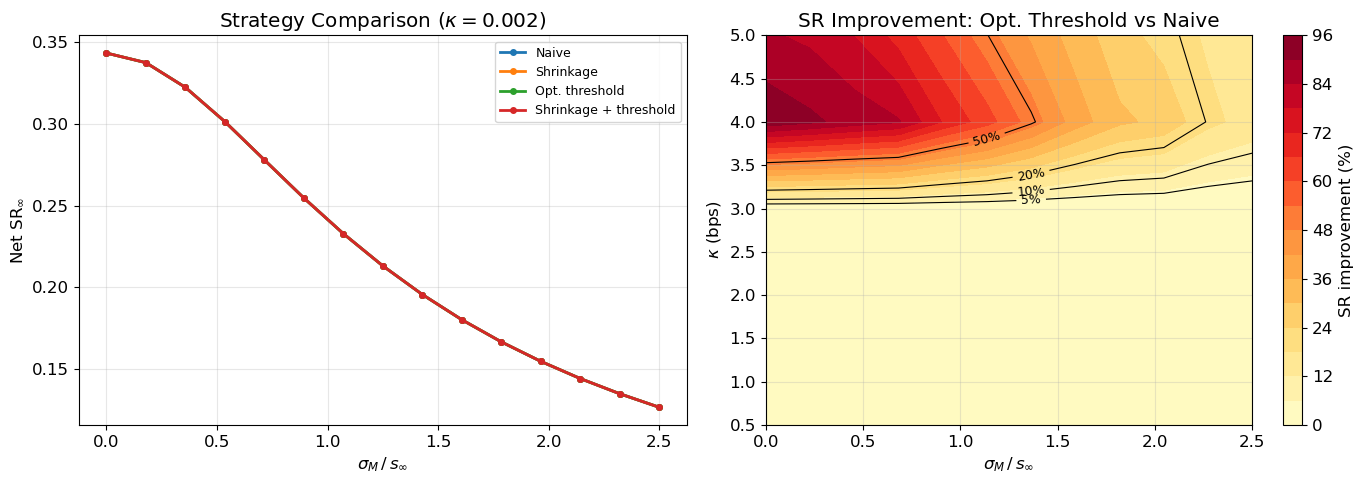

Threshold strategies dominate when both estimation error and costs are moderate.


In [4]:
#| code-fold: true
#| code-summary: "Show simulation code"
#| label: fig-strategy-comparison
#| fig-cap: 'Strategy comparison across estimation error and cost levels. Left: net SR for four strategies at fixed $\kappa = 0.002$. Right: SR improvement of optimal threshold over naive strategy across the $(\sigma_M, \kappa)$ plane.'
# --- Experiment 4: Strategy comparison ---
theta, sigma = 1.0, 0.10
dt = 1 / 252
T = 50
n_paths = 3_000
s_inf = sigma / np.sqrt(2 * theta)
s_inf2 = s_inf**2

X = simulate_ou(theta, sigma, T, dt, n_paths, rng=np.random.default_rng(42))

# Left panel: net SR vs sigma_M for fixed kappa
kappa_fixed = 0.002
sm_scan = np.linspace(0, 2.5, 15)
c_grid = np.linspace(0, 3.0, 30)  # for threshold optimisation

results = {name: [] for name in ['Naive', 'Shrinkage', 'Opt. threshold', 'Shrinkage + threshold']}

for sm_r in sm_scan:
    sig_M = sm_r * s_inf
    M_draw = np.random.default_rng(99).normal(0, sig_M, size=n_paths) if sig_M > 0 else np.zeros(n_paths)
    c = s_inf2 / (s_inf2 + sig_M**2) if sig_M > 0 else 1.0

    # 1. Naive
    results['Naive'].append(compute_sr_with_costs(X, M_draw, g_linear, kappa_fixed, dt, T))

    # 2. Shrinkage
    g_shr = make_g_shrinkage(c)
    results['Shrinkage'].append(compute_sr_with_costs(X, M_draw, g_shr, kappa_fixed, dt, T))

    # 3. Optimal threshold
    best_sr, best_c = -np.inf, 0
    for cr in c_grid:
        g_th = make_g_threshold(cr * s_inf)
        sr = compute_sr_with_costs(X, M_draw, g_th, kappa_fixed, dt, T)
        if sr > best_sr:
            best_sr = sr
            best_c = cr
    results['Opt. threshold'].append(best_sr)

    # 4. Shrinkage + threshold
    best_sr2 = -np.inf
    for cr in c_grid:
        def g_combined(x, c_=c, thresh_=cr * s_inf):
            return c_ * x * (np.abs(x) > thresh_)
        sr = compute_sr_with_costs(X, M_draw, g_combined, kappa_fixed, dt, T)
        if sr > best_sr2:
            best_sr2 = sr
    results['Shrinkage + threshold'].append(best_sr2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

strat_colors = {'Naive': '#1f77b4', 'Shrinkage': '#ff7f0e',
                'Opt. threshold': '#2ca02c', 'Shrinkage + threshold': '#d62728'}
for name, sr_list in results.items():
    axes[0].plot(sm_scan, sr_list, 'o-', ms=4, lw=2, color=strat_colors[name], label=name)

axes[0].set_xlabel(r'$\sigma_M \,/\, s_\infty$')
axes[0].set_ylabel(r'Net $\mathrm{SR}_\infty$')
axes[0].set_title(f'Strategy Comparison ($\\kappa = {kappa_fixed}$)')
axes[0].legend(fontsize=9)

# Right panel: heatmap of SR improvement (opt threshold over naive)
sm_heat = np.linspace(0, 2.5, 12)
kappa_heat = np.array([0.0005, 0.001, 0.0015, 0.002, 0.0025, 0.003, 0.004, 0.005])
improvement = np.zeros((len(kappa_heat), len(sm_heat)))

for i, kap in enumerate(kappa_heat):
    for j, sm_r in enumerate(sm_heat):
        sig_M = sm_r * s_inf
        M_draw = np.random.default_rng(99).normal(0, sig_M, size=n_paths) if sig_M > 0 else np.zeros(n_paths)

        sr_naive = compute_sr_with_costs(X, M_draw, g_linear, kap, dt, T)

        best_sr = sr_naive
        for cr in c_grid:
            g_th = make_g_threshold(cr * s_inf)
            sr = compute_sr_with_costs(X, M_draw, g_th, kap, dt, T)
            if sr > best_sr:
                best_sr = sr

        improvement[i, j] = (best_sr - sr_naive) / max(abs(sr_naive), 1e-10) * 100

SM, KAP = np.meshgrid(sm_heat, kappa_heat)
cf = axes[1].contourf(SM, KAP * 1000, improvement, levels=15, cmap='YlOrRd')
cs = axes[1].contour(SM, KAP * 1000, improvement, levels=[5, 10, 20, 50],
                     colors='k', linewidths=0.8)
axes[1].clabel(cs, fmt='%.0f%%', fontsize=9)
plt.colorbar(cf, ax=axes[1], label='SR improvement (%)')
axes[1].set_xlabel(r'$\sigma_M \,/\, s_\infty$')
axes[1].set_ylabel(r'$\kappa$ (bps)')
axes[1].set_title('SR Improvement: Opt. Threshold vs Naive')

plt.tight_layout()
plt.show()

print("Threshold strategies dominate when both estimation error and costs are moderate.")

# Discussion

The central result of this post is the SR-optimality of the linear position in the frictionless setting (@prp-sr-optimal). The variational proof establishes that the optimal position is proportional to the Bayesian posterior mean $\mathbb{E}[X \mid \tilde{X}]$, which under Gaussian estimation error is linear — implying that no nonlinear signal transformation can improve risk-adjusted return. The naive strategy, despite ignoring estimation error entirely, is already Sharpe-ratio optimal. @fig-sr-optimality confirms this numerically: linear, Bayesian shrinkage, threshold, and cubic position functions all achieve the same SR without costs.

This optimality breaks down when transaction costs are introduced. The linear strategy generates infinite turnover in continuous time, making it inadmissible under any positive cost rate. A dead zone — trading only when $|\tilde{x}| > c^*$ — resolves this by eliminating the most costly small-signal trades. The optimal threshold $c^*$ depends jointly on the estimation error $\sigma_M/s_\infty$ and the cost rate $\kappa/\sigma$, with the two effects reinforcing each other super-additively (@fig-optimal-threshold). Bayesian shrinkage alone helps by reducing turnover proportionally, but the optimal threshold strategy strictly dominates it under costs (@fig-strategy-comparison), since it eliminates small-signal trades entirely rather than merely attenuating them.

The connection to the optimal stopping literature is worth noting. Leung and Li (2015) study optimal entry and exit timing for a binary (long/flat) mean-reversion strategy under fixed per-trade costs, solving a free-boundary problem on the OU generator. Our framework differs in three respects: we optimise over continuous position functions rather than binary entry/exit; we use the path-based Sharpe ratio rather than expected discounted payoff as the objective; and we incorporate estimation error as a central modelling element. Despite these differences, the qualitative structure is similar — costs create a no-trade region, and uncertainty about fair value widens it. The quantitative interaction between estimation error and costs, and the SR-optimality result in the frictionless limit, are to our knowledge new.

Several extensions merit investigation. The position function in the active region may benefit from further refinement: at extreme $|\tilde{x}|$, the OU drift drives fast mean-reversion and high position turnover, suggesting a concave (sublinear) position shape could reduce costs. This connects to the singular stochastic control framework of Leung et al. (2019), which jointly optimises timing and position size under proportional costs. The rolling-estimation setting of Part 4 — where the bias is correlated with the mispricing — would introduce additional structure, since the posterior $\mathbb{E}[X \mid \tilde{X}]$ would no longer be linear, potentially making nonlinear position functions SR-improving even without costs.